In [1]:
import os
import sys

from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import Callback
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning.callbacks import DeviceStatsMonitor, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger
from models.dvRespNet import EventRespirationNet
from aedat_dataset import AEDATRespirationDataset
from datamodule import AEDATDataModule 
import matplotlib.pyplot as plt


In [2]:
def plot_loss_curves(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss', marker='o')
    plt.plot(val_losses, label='Validation Loss', marker='x')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.savefig("loss_curve.png")
    
    
def plot_predictions(y_true, y_pred, title="Predicted vs Ground Truth RR"):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, c='blue', alpha=0.6, label='Predictions')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', label='Ideal')
    plt.xlabel('Ground Truth RR')
    plt.ylabel('Predicted RR')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
    
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    mode="min",
    verbose=True
)

class LossHistory(Callback):
    def __init__(self):
        self.train_losses = []
        self.val_losses = []

    def on_train_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get("train_loss")
        if loss is not None:
            self.train_losses.append(loss.item())

    def on_validation_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get("val_loss")
        if loss is not None:
            self.val_losses.append(loss.item())


checkpoint_callback = ModelCheckpoint(
    dirpath="cpks",
    filename="best_model-{epoch:02d}-{val_loss:.2f}",
    monitor="val_loss",
    save_top_k=1,
    mode="min"
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
You are using a CUDA device ('NVIDIA A100 80GB PCIe') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precisio

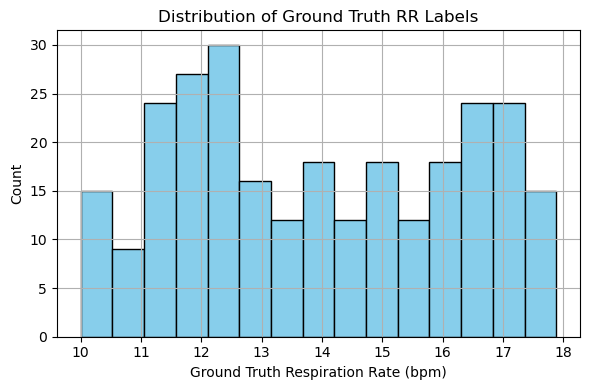

/opt/conda/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/jovyan/work/dvResp/dvRespCNN/cpks exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/conda/lib/python3.11/site-packages/pytorch_lightning/core/optimizer.py:378: Found unsupported keys in the optimizer configuration: {'gradient_clip_val'}

  | Name      | Type       | Params | Mode 
-------------------------------------------------
0 | encoder   | Sequential | 357 K  | train
1 | lstm      | LSTM       | 1.2 M  | train
2 | regressor | Sequential | 8.3 K  | train
-------------------------------------------------
1.5 M     Trainable params
0         Non-trainable params
1.5 M     Total params
6.190     Total estimated model params size (MB)
89        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/conda/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


encoder:
0.conv_t.0.weight - mean: -0.0138, std: 0.1179
0.conv_t.1.0.weight - mean: 1.0000, std: 0.0000
0.conv_t.1.0.bias - mean: 0.0000, std: 0.0000
0.conv_s.0.weight - mean: 0.0020, std: 0.0692
0.conv_s.1.0.weight - mean: 1.0000, std: 0.0000
0.conv_s.1.0.bias - mean: 0.0000, std: 0.0000
1.conv_t.0.weight - mean: -0.0002, std: 0.0454
1.conv_t.1.0.weight - mean: 1.0000, std: 0.0000
1.conv_t.1.0.bias - mean: 0.0000, std: 0.0000
1.conv_s.0.weight - mean: 0.0007, std: 0.0477
1.conv_s.1.0.weight - mean: 1.0000, std: 0.0000
1.conv_s.1.0.bias - mean: 0.0000, std: 0.0000
2.conv_t.0.weight - mean: -0.0002, std: 0.0324
2.conv_t.1.0.weight - mean: 1.0000, std: 0.0000
2.conv_t.1.0.bias - mean: 0.0000, std: 0.0000
2.conv_s.0.weight - mean: 0.0002, std: 0.0482
2.conv_s.1.0.weight - mean: 1.0000, std: 0.0000
2.conv_s.1.0.bias - mean: 0.0000, std: 0.0000
3.conv_t.0.weight - mean: -0.0002, std: 0.0322
3.conv_t.1.0.weight - mean: 1.0000, std: 0.0000
3.conv_t.1.0.bias - mean: 0.0000, std: 0.0000
3.conv_

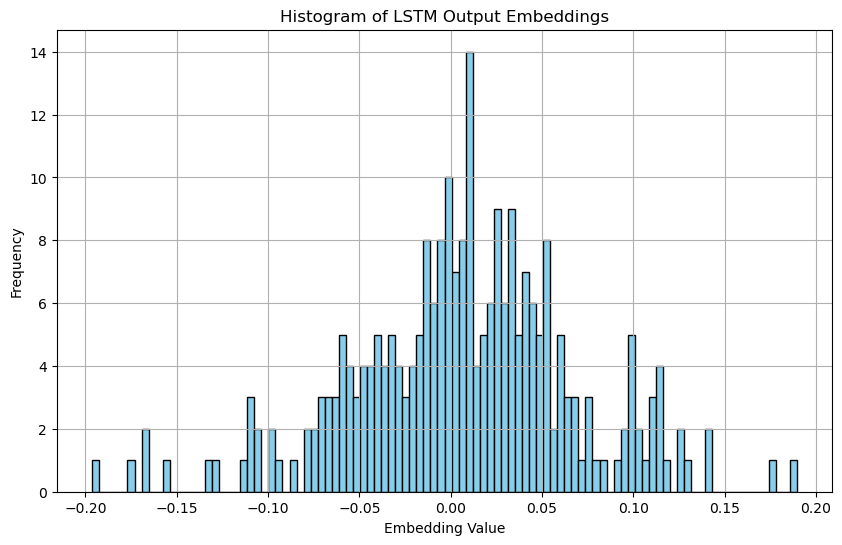

/opt/conda/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

encoder:
0.conv_t.0.weight - mean: -0.0136, std: 0.1179
0.conv_t.1.0.weight - mean: 1.0001, std: 0.0008
0.conv_t.1.0.bias - mean: 0.0010, std: 0.0010
0.conv_s.0.weight - mean: 0.0020, std: 0.0692
0.conv_s.1.0.weight - mean: 1.0000, std: 0.0009
0.conv_s.1.0.bias - mean: 0.0006, std: 0.0017
1.conv_t.0.weight - mean: -0.0003, std: 0.0454
1.conv_t.1.0.weight - mean: 1.0000, std: 0.0005
1.conv_t.1.0.bias - mean: 0.0006, std: 0.0020
1.conv_s.0.weight - mean: 0.0007, std: 0.0477
1.conv_s.1.0.weight - mean: 1.0000, std: 0.0008
1.conv_s.1.0.bias - mean: 0.0006, std: 0.0016
2.conv_t.0.weight - mean: -0.0003, std: 0.0325
2.conv_t.1.0.weight - mean: 1.0000, std: 0.0006
2.conv_t.1.0.bias - mean: 0.0008, std: 0.0015
2.conv_s.0.weight - mean: 0.0004, std: 0.0481
2.conv_s.1.0.weight - mean: 1.0002, std: 0.0010
2.conv_s.1.0.bias - mean: 0.0002, std: 0.0015
3.conv_t.0.weight - mean: -0.0001, std: 0.0322
3.conv_t.1.0.weight - mean: 1.0001, std: 0.0008
3.conv_t.1.0.bias - mean: 0.0002, std: 0.0010
3.conv_

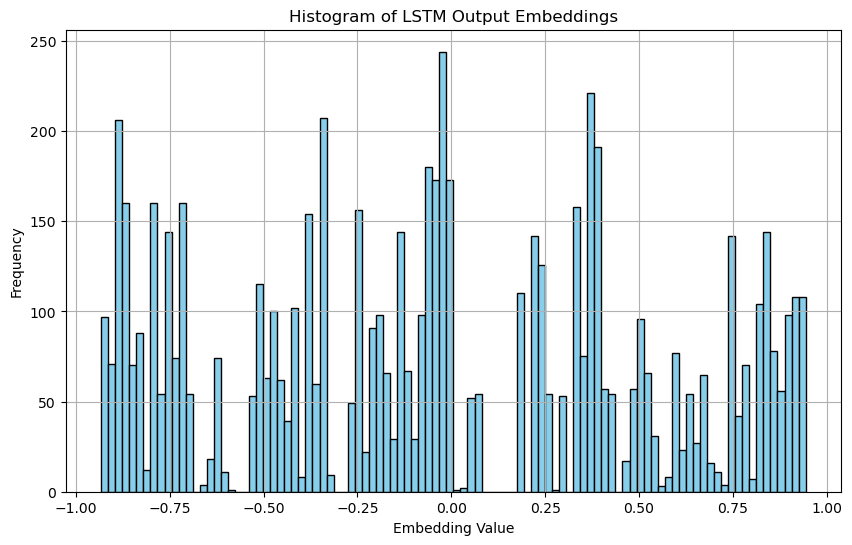

Metric val_loss improved. New best score: 10.796


Validation: |          | 0/? [00:00<?, ?it/s]

encoder:
0.conv_t.0.weight - mean: -0.0135, std: 0.1179
0.conv_t.1.0.weight - mean: 1.0001, std: 0.0008
0.conv_t.1.0.bias - mean: 0.0010, std: 0.0012
0.conv_s.0.weight - mean: 0.0019, std: 0.0692
0.conv_s.1.0.weight - mean: 1.0000, std: 0.0009
0.conv_s.1.0.bias - mean: 0.0007, std: 0.0018
1.conv_t.0.weight - mean: -0.0003, std: 0.0454
1.conv_t.1.0.weight - mean: 0.9999, std: 0.0006
1.conv_t.1.0.bias - mean: 0.0007, std: 0.0022
1.conv_s.0.weight - mean: 0.0006, std: 0.0477
1.conv_s.1.0.weight - mean: 1.0000, std: 0.0009
1.conv_s.1.0.bias - mean: 0.0007, std: 0.0018
2.conv_t.0.weight - mean: -0.0002, std: 0.0325
2.conv_t.1.0.weight - mean: 1.0000, std: 0.0007
2.conv_t.1.0.bias - mean: 0.0009, std: 0.0017
2.conv_s.0.weight - mean: 0.0004, std: 0.0481
2.conv_s.1.0.weight - mean: 1.0002, std: 0.0010
2.conv_s.1.0.bias - mean: 0.0003, std: 0.0017
3.conv_t.0.weight - mean: -0.0002, std: 0.0322
3.conv_t.1.0.weight - mean: 1.0001, std: 0.0009
3.conv_t.1.0.bias - mean: 0.0003, std: 0.0011
3.conv_

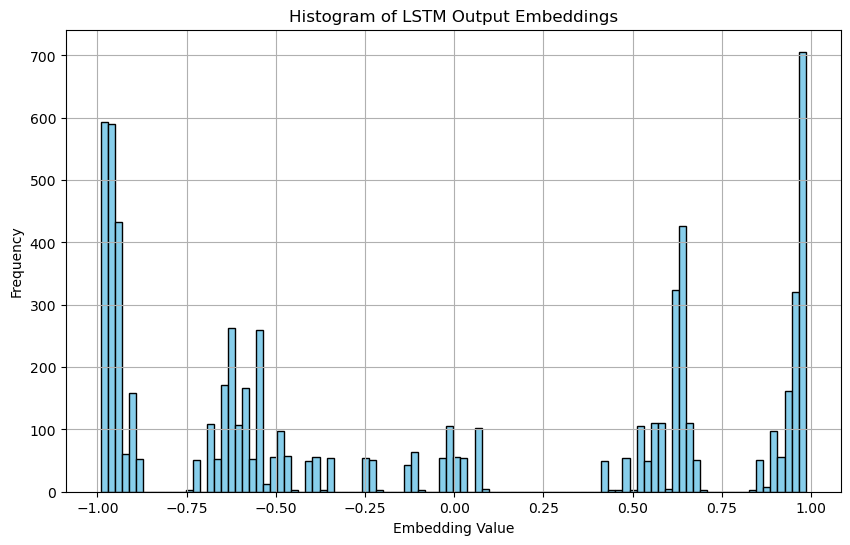

Metric val_loss improved by 5.083 >= min_delta = 0.0. New best score: 5.713


Validation: |          | 0/? [00:00<?, ?it/s]

encoder:
0.conv_t.0.weight - mean: -0.0135, std: 0.1179
0.conv_t.1.0.weight - mean: 1.0001, std: 0.0008
0.conv_t.1.0.bias - mean: 0.0010, std: 0.0013
0.conv_s.0.weight - mean: 0.0019, std: 0.0692
0.conv_s.1.0.weight - mean: 1.0000, std: 0.0009
0.conv_s.1.0.bias - mean: 0.0007, std: 0.0019
1.conv_t.0.weight - mean: -0.0003, std: 0.0454
1.conv_t.1.0.weight - mean: 0.9999, std: 0.0006
1.conv_t.1.0.bias - mean: 0.0007, std: 0.0023
1.conv_s.0.weight - mean: 0.0006, std: 0.0477
1.conv_s.1.0.weight - mean: 0.9999, std: 0.0009
1.conv_s.1.0.bias - mean: 0.0007, std: 0.0019
2.conv_t.0.weight - mean: -0.0002, std: 0.0325
2.conv_t.1.0.weight - mean: 1.0000, std: 0.0007
2.conv_t.1.0.bias - mean: 0.0009, std: 0.0018
2.conv_s.0.weight - mean: 0.0004, std: 0.0481
2.conv_s.1.0.weight - mean: 1.0002, std: 0.0010
2.conv_s.1.0.bias - mean: 0.0003, std: 0.0017
3.conv_t.0.weight - mean: -0.0002, std: 0.0322
3.conv_t.1.0.weight - mean: 1.0001, std: 0.0010
3.conv_t.1.0.bias - mean: 0.0003, std: 0.0011
3.conv_

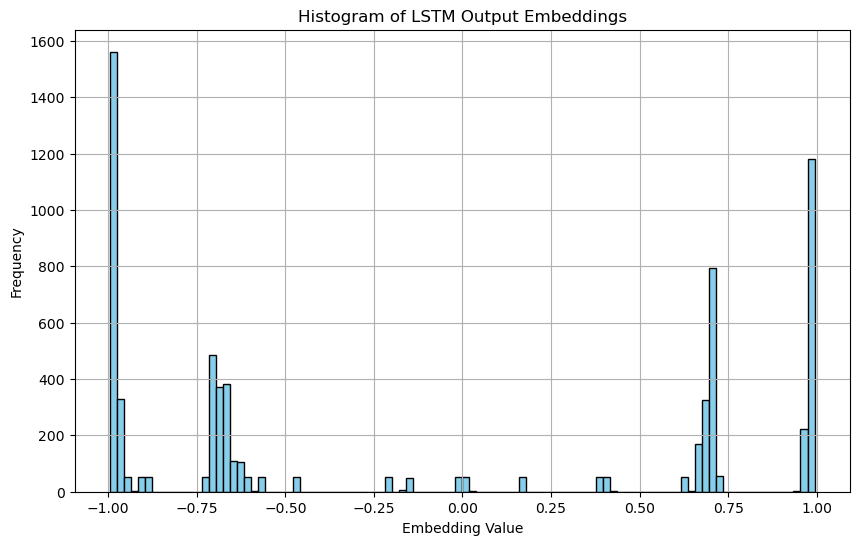

Metric val_loss improved by 4.105 >= min_delta = 0.0. New best score: 1.608


Validation: |          | 0/? [00:00<?, ?it/s]

encoder:
0.conv_t.0.weight - mean: -0.0135, std: 0.1179
0.conv_t.1.0.weight - mean: 1.0001, std: 0.0009
0.conv_t.1.0.bias - mean: 0.0010, std: 0.0013
0.conv_s.0.weight - mean: 0.0019, std: 0.0692
0.conv_s.1.0.weight - mean: 1.0000, std: 0.0009
0.conv_s.1.0.bias - mean: 0.0007, std: 0.0019
1.conv_t.0.weight - mean: -0.0003, std: 0.0454
1.conv_t.1.0.weight - mean: 0.9999, std: 0.0006
1.conv_t.1.0.bias - mean: 0.0007, std: 0.0023
1.conv_s.0.weight - mean: 0.0006, std: 0.0477
1.conv_s.1.0.weight - mean: 0.9999, std: 0.0009
1.conv_s.1.0.bias - mean: 0.0007, std: 0.0019
2.conv_t.0.weight - mean: -0.0002, std: 0.0325
2.conv_t.1.0.weight - mean: 1.0000, std: 0.0007
2.conv_t.1.0.bias - mean: 0.0009, std: 0.0018
2.conv_s.0.weight - mean: 0.0004, std: 0.0481
2.conv_s.1.0.weight - mean: 1.0002, std: 0.0010
2.conv_s.1.0.bias - mean: 0.0003, std: 0.0017
3.conv_t.0.weight - mean: -0.0002, std: 0.0322
3.conv_t.1.0.weight - mean: 1.0001, std: 0.0010
3.conv_t.1.0.bias - mean: 0.0003, std: 0.0011
3.conv_

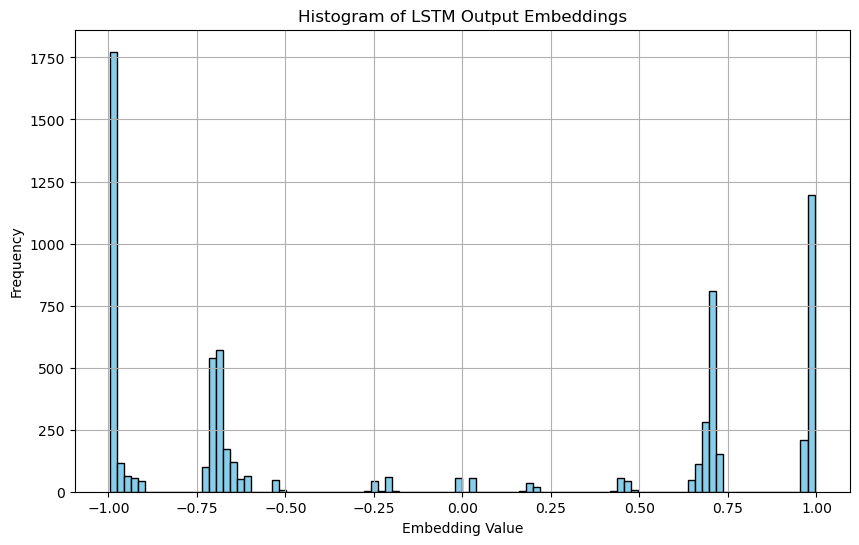

Metric val_loss improved by 0.029 >= min_delta = 0.0. New best score: 1.579


In [ ]:
    # 1) Instantiate model
    model = EventRespirationNet(lr=5e-5)
    loss_history_cb = LossHistory()

    # 2) Instantiate DataModule pointing at your AEDAT folder and GT CSV
    data_module = AEDATDataModule(
        data_dir="../data/042025",
        csv_path="../data/ground_truth.csv",
        batch_size=1, 
        frames_per_sample=100,
        max_time=10,
        filtered=False,
        plot_labels = True
    )

    # 3) Trainer
    trainer = Trainer(
        max_epochs=50,
        callbacks=[loss_history_cb, early_stop, DeviceStatsMonitor(), checkpoint_callback],
        accelerator="auto",
        devices="auto",
        log_every_n_steps=10
    )

    # 4) Fit
    trainer.fit(model, datamodule=data_module)
    
    plot_loss_curves(loss_history_cb.train_losses, loss_history_cb.val_losses)